# Monthly Sales Trend
Analysing revenue and order volume trends across the Olist dataset period (2016–2018).

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

client = bigquery.Client(project='dataai-project-0')

E0000 00:00:1780300493.939191  153010 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1780300493.939496  153010 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1780300493.939508  153010 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1780300493.939514  153010 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1780300493.939519  153010 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


## EDA — Sanity Checks

In [2]:
eda = client.query("""
    SELECT
        COUNT(*)                        AS total_rows,
        COUNT(DISTINCT order_id)        AS unique_orders,
        COUNT(DISTINCT customer_id)     AS unique_customers,
        MIN(order_date)                 AS earliest_date,
        MAX(order_date)                 AS latest_date,
        COUNTIF(total_amount IS NULL)   AS null_total_amount,
        ROUND(AVG(total_amount), 2)     AS avg_order_item_value
    FROM `dataai-project-0.gold.fact_orders`
""").to_dataframe()

print(eda.to_string(index=False))

/home/seanwong/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


 total_rows  unique_orders  unique_customers earliest_date latest_date  null_total_amount  avg_order_item_value
     112650          98666             98666    2016-09-04  2018-09-03                  0                140.64


## Analysis — Monthly Revenue & Order Volume

In [3]:
df = client.query("""
    SELECT
        DATE_TRUNC(order_date, MONTH)       AS month,
        ROUND(SUM(total_amount), 2)         AS revenue,
        COUNT(DISTINCT order_id)            AS orders,
        ROUND(SUM(total_amount) / COUNT(DISTINCT order_id), 2) AS avg_order_value
    FROM `dataai-project-0.gold.fact_orders`
    WHERE order_date >= '2017-01-01'
    GROUP BY 1
    ORDER BY 1
""").to_dataframe()

df['month'] = pd.to_datetime(df['month'])
df['mom_growth'] = df['revenue'].pct_change() * 100
df.head()

/home/seanwong/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,month,revenue,orders,avg_order_value,mom_growth
0,2017-01-01,137188.49,789,173.88,NaN
1,2017-02-01,286280.62,1733,165.19,108.676850
2,2017-03-01,432048.59,2641,163.59,50.917862
3,2017-04-01,412422.24,2391,172.49,-4.542626
4,2017-05-01,586190.95,3660,160.16,42.133690


## Key Metrics

In [4]:
peak = df.loc[df['revenue'].idxmax()]
total_revenue = df['revenue'].sum()
avg_mom_growth = df['mom_growth'].mean()

print(f"Total revenue (2017–2018): R$ {total_revenue:,.2f}")
print(f"Peak month: {peak['month'].strftime('%B %Y')} — R$ {peak['revenue']:,.2f}")
print(f"Peak order volume: {int(peak['orders']):,} orders")
print(f"Average MoM growth: {avg_mom_growth:.1f}%")
print(f"Average order value: R$ {df['avg_order_value'].mean():,.2f}")

Total revenue (2017–2018): R$ 15,786,370.03
Peak month: November 2017 — R$ 1,179,143.77
Peak order volume: 7,451 orders
Average MoM growth: 8.8%
Average order value: R$ 161.81


## Visualisation

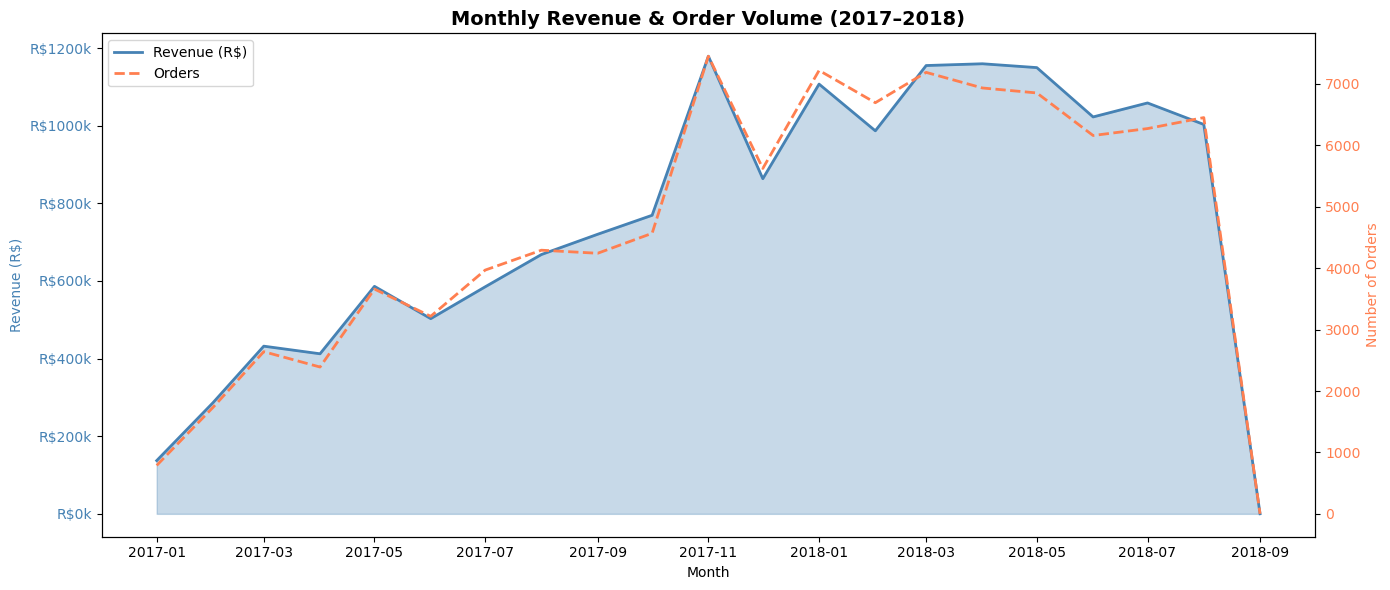

In [5]:
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.fill_between(df['month'], df['revenue'], alpha=0.3, color='steelblue')
ax1.plot(df['month'], df['revenue'], color='steelblue', linewidth=2, label='Revenue (R$)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (R$)', color='steelblue')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(df['month'], df['orders'], color='coral', linewidth=2, linestyle='--', label='Orders')
ax2.set_ylabel('Number of Orders', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Monthly Revenue & Order Volume (2017–2018)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Business Recommendation

**Finding:** Revenue peaked in November 2017, driven by Black Friday — the single highest revenue month in the dataset. Orders and revenue track closely, suggesting average order value is relatively stable.

**Recommendation:** Olist should plan inventory and logistics capacity around Q3–Q4 each year, with particular focus on November. A targeted promotional campaign in October (pre-Black Friday) could capture early shoppers and smooth the demand spike, reducing fulfilment pressure in peak week.